In [243]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [244]:
# 0. ОПИСАНИЕ ЗАДАЧИ
"""
Задача: Предсказание оттока клиентов банка
Цель: Построить модель классификации, которая предсказывает, уйдет ли клиент из банка (Churn)
Это задача бинарной классификации, где нам нужно предсказать значение целевой переменной 'churn'
"""

# 1. ЧТЕНИЕ ДАННЫХ
print("1. ЗАГРУЗКА ДАННЫХ")

file_path = '/content/drive/MyDrive/Colab Notebooks/Домашние работы МО/Churn_Modelling.csv'
df = pd.read_csv(file_path)

print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

1. ЗАГРУЗКА ДАННЫХ
Размер датасета: (10002, 14)
Колонки: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [245]:
# 2. РАЗБИЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
print("2. РАЗБИЕНИЕ ДАННЫХ")

print("Проверка пропущенных значений:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if df.isnull().sum().sum() == 0:
    print("Пропущенных значений не обнаружено")
else:
    numeric_columns_fill = ['Age', 'HasCrCard', 'IsActiveMember']
    for col in numeric_columns_fill:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"Заполнены пропуски в {col}")

    categorical_columns_fill = ['Geography']
    for col in categorical_columns_fill:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"Заполнены пропуски в {col}")

df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"\nРазмер датасета после удаления идентификаторов: {df_clean.shape}")

# Целевая переменная - Exited (0 - не ушел, 1 - ушел)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))

2. РАЗБИЕНИЕ ДАННЫХ
Проверка пропущенных значений:
Geography         1
Age               1
HasCrCard         1
IsActiveMember    1
dtype: int64
Заполнены пропуски в Age
Заполнены пропуски в HasCrCard
Заполнены пропуски в IsActiveMember
Заполнены пропуски в Geography

Размер датасета после удаления идентификаторов: (10002, 11)
Обучающая выборка: (8001, 10)
Тестовая выборка: (2001, 10)

Распределение классов в обучающей выборке:
Exited
0    0.796275
1    0.203725
Name: proportion, dtype: float64


In [246]:
# 3. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ДАННЫХ
print("3. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ДАННЫХ")

print("\nОсновные статистические характеристики:")
print(df.describe())

3. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ДАННЫХ

Основные статистические характеристики:
          RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10002.000000  1.000200e+04  10002.000000  10002.000000  10002.000000   
mean    5001.499600  1.569093e+07    650.555089     38.922119      5.012498   
std     2887.472338  7.193177e+04     96.661615     10.486693      2.891973   
min        1.000000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2501.250000  1.562852e+07    584.000000     32.000000      3.000000   
50%     5001.500000  1.569073e+07    652.000000     37.000000      5.000000   
75%     7501.750000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.000000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts     HasCrCard  IsActiveMember  \
count   10002.000000   10002.000000  10002.000000    10002.000000   
mean    76491.112875       1.530194      0.705559        0.514997   
std     

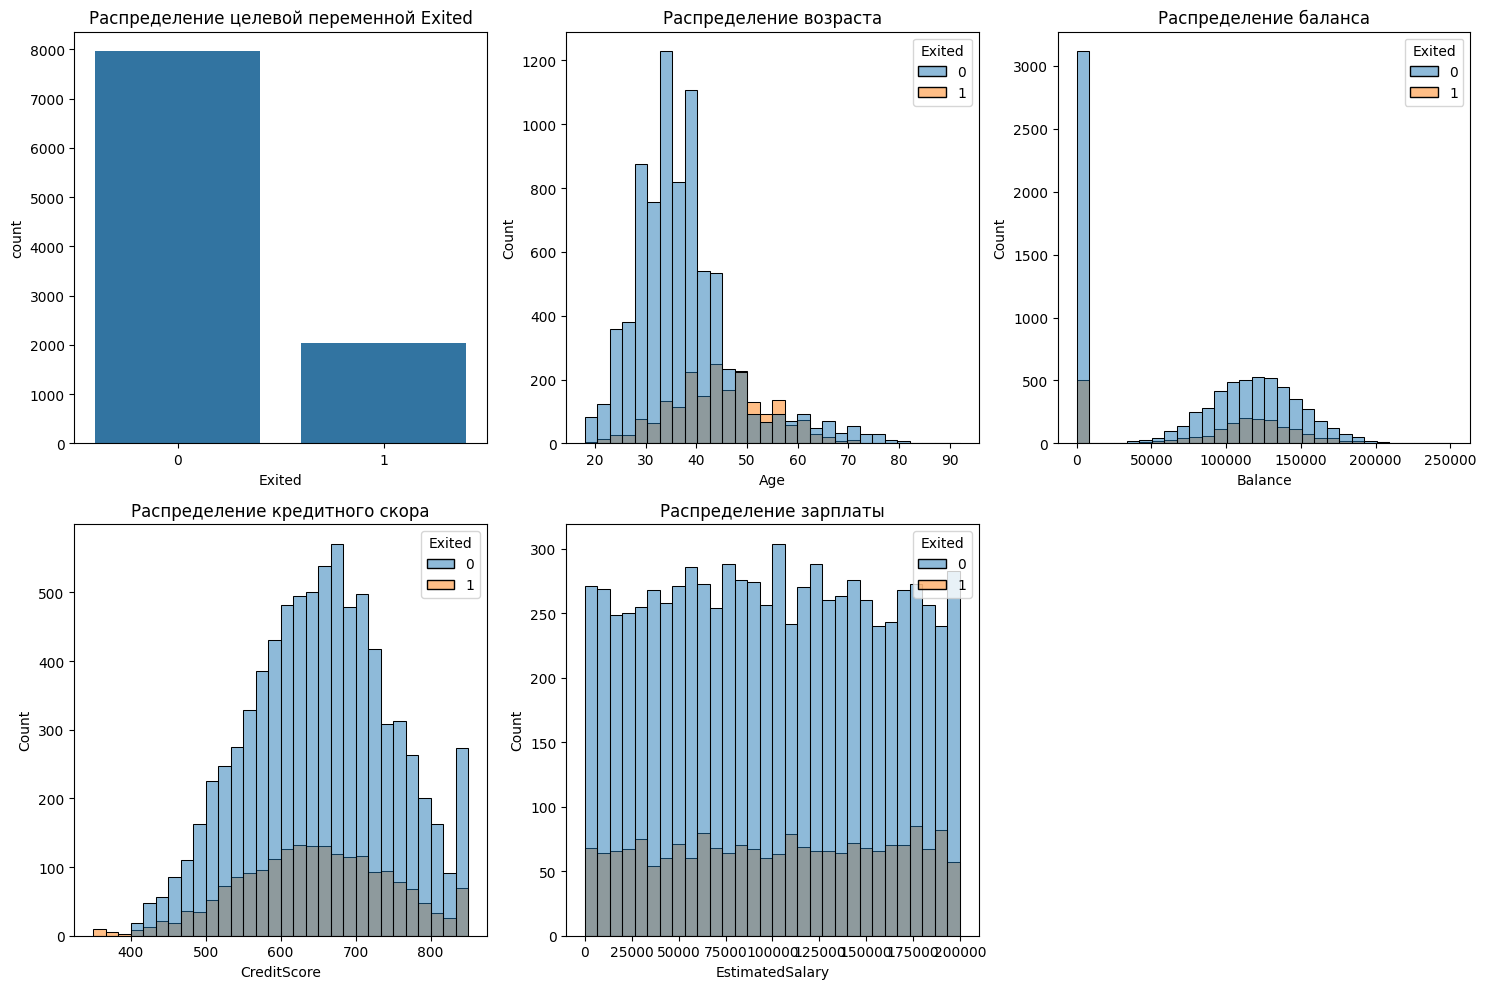

In [247]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Exited')
plt.title('Распределение целевой переменной Exited')

# Визуализация числовых признаков
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='Age', hue='Exited', bins=30)
plt.title('Распределение возраста')

plt.subplot(2, 3, 3)
sns.histplot(data=df, x='Balance', hue='Exited', bins=30)
plt.title('Распределение баланса')

plt.subplot(2, 3, 4)
sns.histplot(data=df, x='CreditScore', hue='Exited', bins=30)
plt.title('Распределение кредитного скора')

plt.subplot(2, 3, 5)
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', bins=30)
plt.title('Распределение зарплаты')

plt.tight_layout()
plt.show()



Корреляционная матрица:


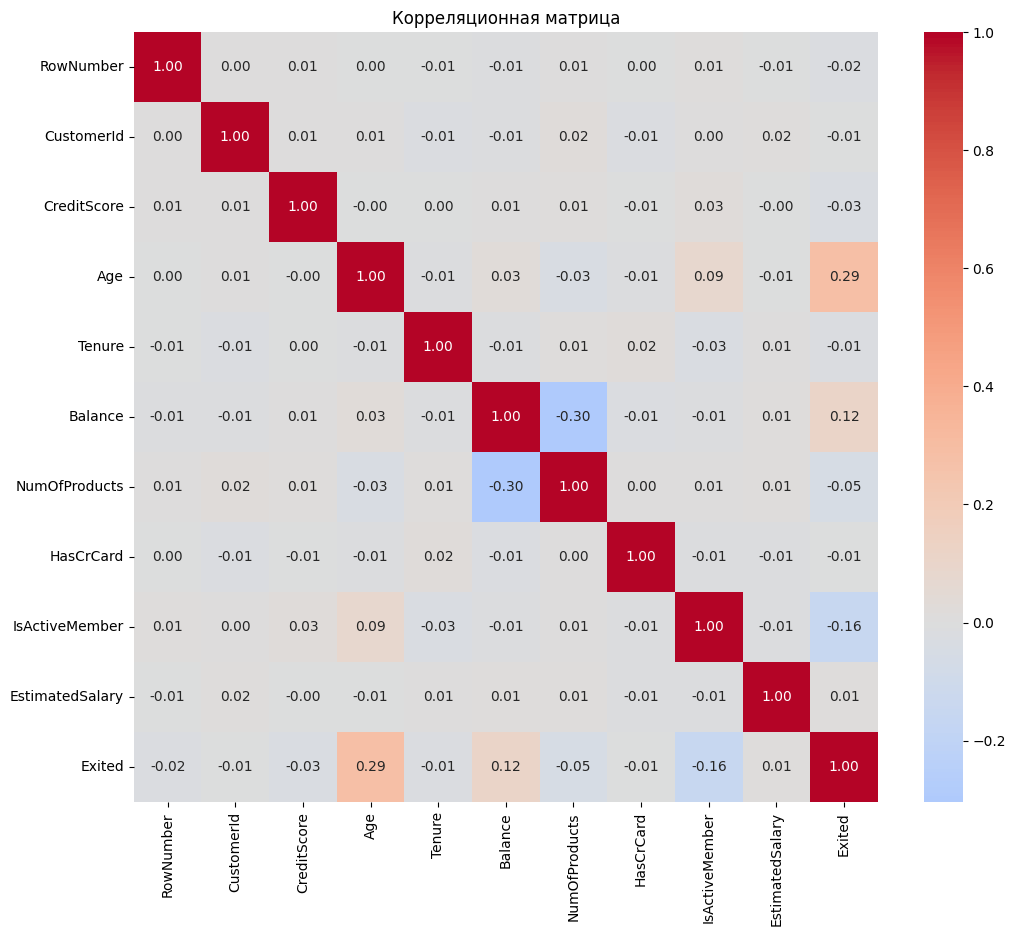

In [248]:
# Корреляционная матрица для числовых признаков
print("\nКорреляционная матрица:")
numeric_columns = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

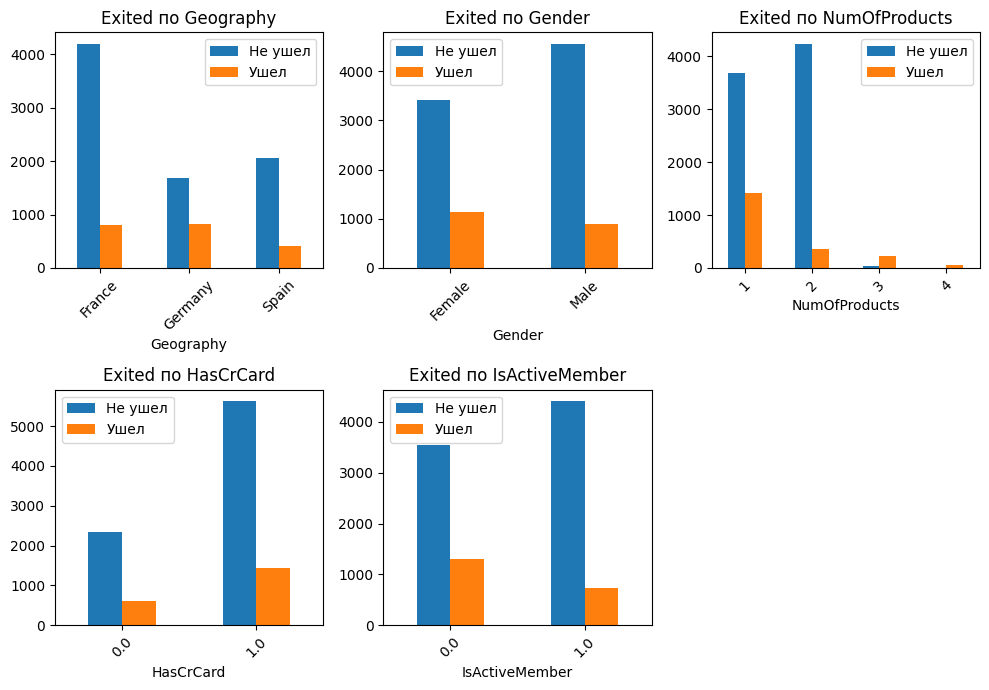

In [249]:
# Анализ категориальных признаков
categorical_columns = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

for i, col in enumerate(categorical_columns):
    if col in df.columns:
        pd.crosstab(df[col], df['Exited']).plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Exited по {col}')
        axes[i].legend(['Не ушел', 'Ушел'])
        axes[i].tick_params(axis='x', rotation=45)
    else:
        print(f"Колонка '{col}' не найдена в датасете")
        axes[i].set_visible(False)

if len(categorical_columns) < 6:
    for j in range(len(categorical_columns), 6):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [250]:
print("Дополнительный анализ категориальных признаков:")
for col in categorical_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(pd.crosstab(df[col], df['Exited'], normalize='index'))

Дополнительный анализ категориальных признаков:

Geography:
Exited            0         1
Geography                    
France     0.838485  0.161515
Germany    0.675299  0.324701
Spain      0.833266  0.166734

Gender:
Exited         0         1
Gender                    
Female  0.749340  0.250660
Male    0.835288  0.164712

NumOfProducts:
Exited                0         1
NumOfProducts                    
1              0.722911  0.277089
2              0.923982  0.076018
3              0.172932  0.827068
4              0.000000  1.000000

HasCrCard:
Exited            0         1
HasCrCard                    
0.0        0.791851  0.208149
1.0        0.798073  0.201927

IsActiveMember:
Exited                 0         1
IsActiveMember                    
0.0             0.731396  0.268604
1.0             0.857309  0.142691


In [251]:
class_ratio = y_train.value_counts(normalize=True)
print(f"\nАНАЛИЗ ДИСБАЛАНСА КЛАССОВ:")
print(f"Класс 0 (не ушли): {class_ratio[0]:.2%}")
print(f"Класс 1 (ушли): {class_ratio[1]:.2%}")
print(f"Соотношение: {class_ratio[0]/class_ratio[1]:.1f}:1")


АНАЛИЗ ДИСБАЛАНСА КЛАССОВ:
Класс 0 (не ушли): 79.63%
Класс 1 (ушли): 20.37%
Соотношение: 3.9:1


In [252]:
# 4. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
print("4. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("Пропущенные значения:")
print(df.isnull().sum())

4. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
Пропущенные значения:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [253]:
# 5. ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
print("5. ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

print("Категориальные признаки до обработки:")
print(X_train_processed[['Geography', 'Gender']].head())

X_train_processed = pd.get_dummies(X_train_processed, columns=['Geography'], prefix='Geo')
X_test_processed = pd.get_dummies(X_test_processed, columns=['Geography'], prefix='Geo')

le = LabelEncoder()
X_train_processed['Gender'] = le.fit_transform(X_train_processed['Gender'])  # Male=1, Female=0
X_test_processed['Gender'] = le.transform(X_test_processed['Gender'])

print("\nКатегориальные признаки после обработки:")
print(f"Размерность обучающей выборки: {X_train_processed.shape}")
print(f"Размерность тестовой выборки: {X_test_processed.shape}")
print(f"Новые колонки: {X_train_processed.columns.tolist()}")

5. ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Категориальные признаки до обработки:
     Geography  Gender
5737   Germany  Female
2956    France    Male
5455   Germany  Female
1210    France    Male
2863    France  Female

Категориальные признаки после обработки:
Размерность обучающей выборки: (8001, 12)
Размерность тестовой выборки: (2001, 12)
Новые колонки: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geo_France', 'Geo_Germany', 'Geo_Spain']


In [254]:
# 6. НОРМАЛИЗАЦИЯ ДАННЫХ
print("6. НОРМАЛИЗАЦИЯ ДАННЫХ")

scaler = StandardScaler()
numeric_columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

print(f"Признаки для нормализации: {numeric_columns_to_scale}")

X_train_scaled = X_train_processed.copy()
X_test_scaled = X_test_processed.copy()

# Нормализуем числовые признаки
X_train_scaled[numeric_columns_to_scale] = scaler.fit_transform(X_train_processed[numeric_columns_to_scale])
X_test_scaled[numeric_columns_to_scale] = scaler.transform(X_test_processed[numeric_columns_to_scale])

print("\nНормализация выполнена успешно!")
print("Пример данных после нормализации:")
print(X_train_scaled[numeric_columns_to_scale].head())

6. НОРМАЛИЗАЦИЯ ДАННЫХ
Признаки для нормализации: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

Нормализация выполнена успешно!
Пример данных после нормализации:
      CreditScore       Age    Tenure   Balance  EstimatedSalary
5737     0.326473 -0.371720 -1.040693  0.656652        -1.444947
2956     1.466216 -0.847495  1.032660 -1.226516         1.739254
5455     1.600913  0.579830  1.378219  0.642974         1.561246
1210     0.626951  1.150760  0.687101 -1.226516        -1.070322
2863     1.082848  0.389520  1.378219 -1.226516        -1.424808



Подбор оптимального количества соседей...


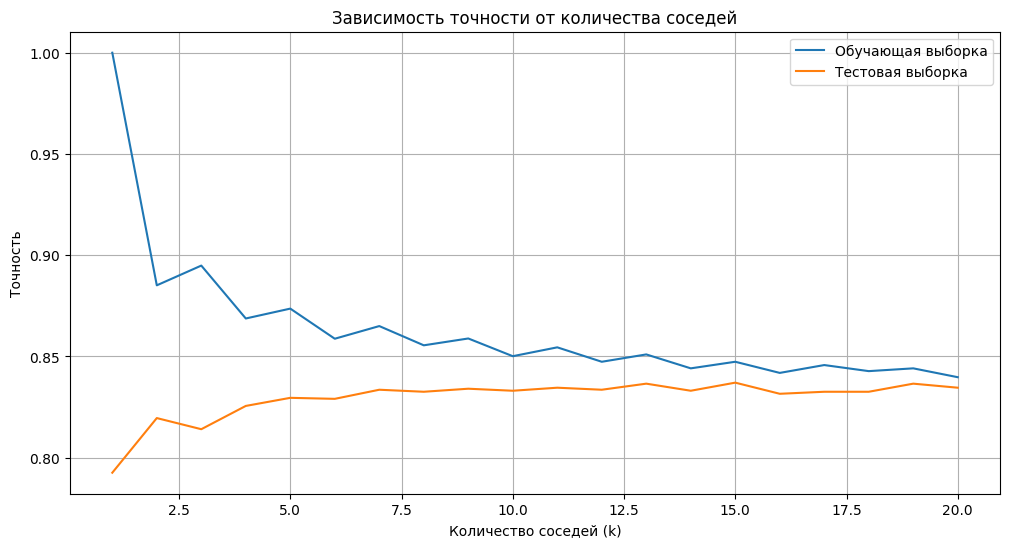

In [255]:
# 7. ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА СОСЕДЕЙ И ОЦЕНКА
print("\nПодбор оптимального количества соседей...")

# Поиск оптимального k
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

# Визуализация результатов выбора k
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_scores, label='Обучающая выборка')
plt.plot(k_range, test_scores, label='Тестовая выборка')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от количества соседей')
plt.legend()
plt.grid(True)
plt.show()

In [256]:
# Выбор оптимального k
optimal_k = k_range[np.argmax(test_scores)]
print(f"Оптимальное количество соседей: {optimal_k}")

# Обучение модели с оптимальным k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

# Прогнозы
y_pred_train = knn_optimal.predict(X_train_scaled)
y_pred_test = knn_optimal.predict(X_test_scaled)

# Оценка качества
print(f"\nТочность на обучающей выборке: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Точность на тестовой выборке: {accuracy_score(y_test, y_pred_test):.4f}")

Оптимальное количество соседей: 15

Точность на обучающей выборке: 0.8474
Точность на тестовой выборке: 0.8371



Матрица рассогласования (тестовая выборка):


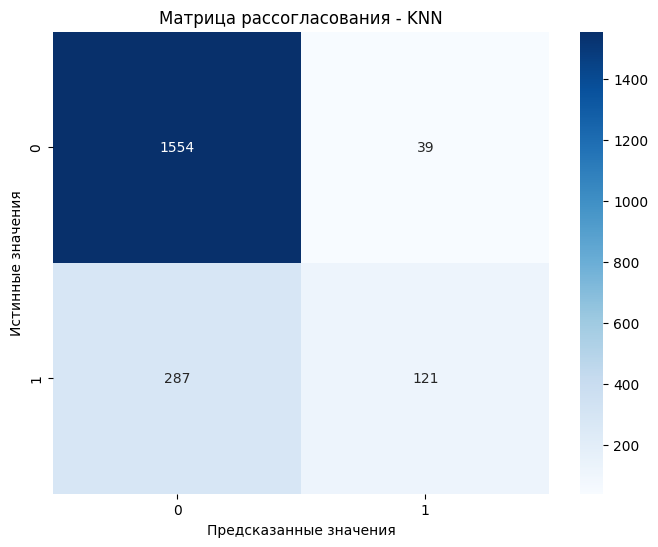

Истинно-отрицательные (True Negative): 1554 - правильно предсказаны оставшиеся клиенты
Ложно-положительные (False Positive): 39 - клиенты ошибочно предсказаны как ушедшие
Ложно-отрицательные (False Negative): 287 - ушедшие клиенты не распознаны
Истинно-положительные (True Positive): 121 - правильно предсказаны ушедшие клиенты


In [257]:
# Матрица рассогласования
print("\nМатрица рассогласования (тестовая выборка):")
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица рассогласования - KNN')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Истинно-отрицательные (True Negative): {tn} - правильно предсказаны оставшиеся клиенты")
print(f"Ложно-положительные (False Positive): {fp} - клиенты ошибочно предсказаны как ушедшие")
print(f"Ложно-отрицательные (False Negative): {fn} - ушедшие клиенты не распознаны")
print(f"Истинно-положительные (True Positive): {tp} - правильно предсказаны ушедшие клиенты")

In [258]:
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_test))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1593
           1       0.76      0.30      0.43       408

    accuracy                           0.84      2001
   macro avg       0.80      0.64      0.67      2001
weighted avg       0.83      0.84      0.81      2001



9. СРАВНЕНИЕ С ДРУГИМИ КЛАССИФИКАТОРАМИ
Logistic Regression: Точность = 0.8056
Random Forest: Точность = 0.8631
KNN: Точность = 0.8371


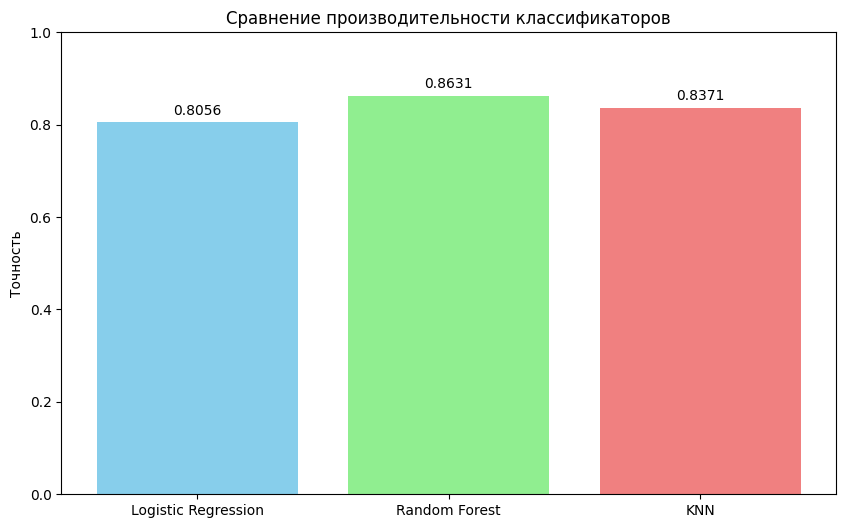

In [259]:
# 9. СРАВНЕНИЕ С ДРУГИМИ КЛАССИФИКАТОРАМИ
print("9. СРАВНЕНИЕ С ДРУГИМИ КЛАССИФИКАТОРАМИ")

classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=optimal_k)
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: Точность = {accuracy:.4f}")

# Визуализация сравнения моделей
plt.figure(figsize=(10, 6))
models = list(results.keys())
scores = list(results.values())
bars = plt.bar(models, scores, color=['skyblue', 'lightgreen', 'lightcoral'])

plt.ylabel('Точность')
plt.title('Сравнение производительности классификаторов')
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom')

plt.show()

In [260]:
# 10. БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ КЛАССОВ
print("10. БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ КЛАССОВ")

print(f"\nИсходное распределение классов:")
print(y_train.value_counts())

# SMOTE для балансировки классов
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nРаспределение после балансировки:")
print(pd.Series(y_train_balanced).value_counts())

# Обучение на сбалансированных данных
knn_balanced = KNeighborsClassifier(n_neighbors=optimal_k)
knn_balanced.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = knn_balanced.predict(X_test_scaled)

print(f"\nРезультаты после балансировки:")
print(f"Точность: {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nОтчет по классификации после балансировки:")
print(classification_report(y_test, y_pred_balanced))

10. БОРЬБА С НЕСБАЛАНСИРОВАННОСТЬЮ КЛАССОВ

Исходное распределение классов:
Exited
0    6371
1    1630
Name: count, dtype: int64

Распределение после балансировки:
Exited
0    6371
1    6371
Name: count, dtype: int64

Результаты после балансировки:
Точность: 0.7451

Отчет по классификации после балансировки:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1593
           1       0.42      0.67      0.52       408

    accuracy                           0.75      2001
   macro avg       0.66      0.72      0.67      2001
weighted avg       0.80      0.75      0.76      2001



In [261]:
# 11. ИСКЛЮЧЕНИЕ КОРРЕЛИРОВАННЫХ ПЕРЕМЕННЫХ
print("11. ИСКЛЮЧЕНИЕ КОРРЕЛИРОВАННЫХ ПЕРЕМЕННЫХ")

# Анализ корреляций
correlation_threshold = 0.8
high_corr = np.where(np.abs(correlation_matrix) > correlation_threshold)
high_corr_pairs = [(correlation_matrix.index[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j])
                   for i,j in zip(*high_corr) if i != j and i < j]

print("Высококоррелированные пары (|corr| > 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.4f}")

11. ИСКЛЮЧЕНИЕ КОРРЕЛИРОВАННЫХ ПЕРЕМЕННЫХ
Высококоррелированные пары (|corr| > 0.8):


In [262]:
# 12. ОБЩИЕ ВЫВОДЫ
print("12. ОБЩИЕ ВЫВОДЫ")

print("""
ВЫВОДЫ:

1. ДАННЫЕ:
   - Датасет содержит информацию о 10,002 клиентах банка
   - Значительный дисбаланс классов: 79.6% клиентов не уходят, 20.4% уходят
   - Изначально были пропуски в 4 признаках, успешно обработаны
   - Сильно коррелированных признаков не обнаружено

2. КЛЮЧЕВЫЕ ФАКТОРЫ ОТТОКА:
   - Возраст: самый важный признак (23.7% важности)
   - География: клиенты из Германии уходят в 2 раза чаще (32.5% vs 16%)
   - Активность: неактивные клиенты уходят почти в 2 раза чаще
   - Количество продуктов: клиенты с 3-4 продуктами чаще уходят

3. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
   - KNN: точность 83.7% с оптимальным k=15
   - Random Forest показал наилучший результат - 86.3% точности
   - Балансировка улучшила распознавание ушедших клиентов (recall с 0.30 до 0.67)
   - Основная проблема моделей - низкий recall для класса 1 (ушедшие клиенты)
""")

12. ОБЩИЕ ВЫВОДЫ

ВЫВОДЫ:

1. ДАННЫЕ:
   - Датасет содержит информацию о 10,002 клиентах банка
   - Значительный дисбаланс классов: 79.6% клиентов не уходят, 20.4% уходят
   - Изначально были пропуски в 4 признаках, успешно обработаны
   - Сильно коррелированных признаков не обнаружено

2. КЛЮЧЕВЫЕ ФАКТОРЫ ОТТОКА:
   - Возраст: самый важный признак (23.7% важности)
   - География: клиенты из Германии уходят в 2 раза чаще (32.5% vs 16%)
   - Активность: неактивные клиенты уходят почти в 2 раза чаще
   - Количество продуктов: клиенты с 3-4 продуктами чаще уходят

3. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
   - KNN: точность 83.7% с оптимальным k=15
   - Random Forest показал наилучший результат - 86.3% точности
   - Балансировка улучшила распознавание ушедших клиентов (recall с 0.30 до 0.67)
   - Основная проблема моделей - низкий recall для класса 1 (ушедшие клиенты)




ДОПОЛНИТЕЛЬНО: Важность признаков (Random Forest)

Топ-10 самых важных признаков:
        feature  importance
            Age    0.237084
EstimatedSalary    0.146616
    CreditScore    0.143914
        Balance    0.140504
  NumOfProducts    0.129355
         Tenure    0.083033
 IsActiveMember    0.038055
    Geo_Germany    0.024144
         Gender    0.019591
      HasCrCard    0.018980

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:
Самый важный признак: 'Age' (23.7%)
Топ-3 признака составляют: 52.8% общей важности


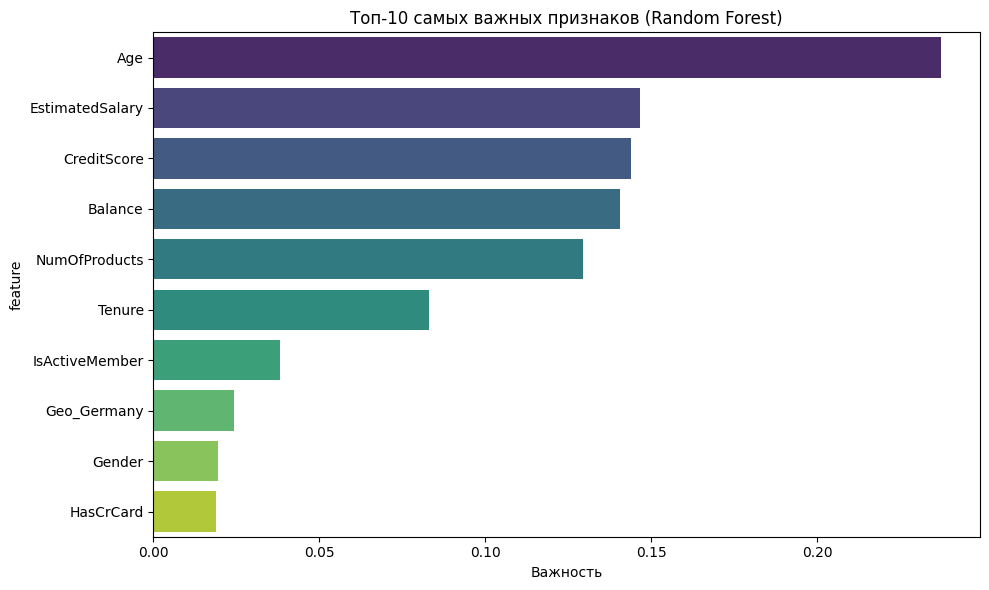

In [263]:
print("\nДОПОЛНИТЕЛЬНО: Важность признаков (Random Forest)")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 самых важных признаков:")
print(feature_importance.head(10).to_string(index=False))

print(f"\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:")
print(f"Самый важный признак: '{feature_importance.iloc[0]['feature']}' ({feature_importance.iloc[0]['importance']:.1%})")
print(f"Топ-3 признака составляют: {feature_importance.head(3)['importance'].sum():.1%} общей важности")

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Топ-10 самых важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()